# 🏨 Atlantic Haven Hotels — Prédiction d'annulation de réservation
### Hackathon ML & Data Science — M1 ISPM — Version corrigée

**Objectif :** prédire `reservation_annulee` (0 = maintenue, 1 = annulée), fournir une probabilité et une décision binaire, et maximiser le **F1-score** sur la classe « annulation », en respectant l'ordre temporel des données.

**Corrections apportées par rapport à la première version :**
1. Le **split temporel train/validation est fait avant toute imputation** des valeurs manquantes, pour que les statistiques d'imputation (médianes, modes) n'utilisent jamais d'information issue de la période de validation.
2. Une seule cellule finale, propre, génère `submission.csv` (plus de cellules redondantes qui s'écrasent).
3. La démonstration du gain du feature engineering (Étape 4) est **calculée dynamiquement**, plus aucune valeur n'est recopiée à la main.
4. Le modèle final est **ré-entraîné sur l'intégralité des données d'entraînement** (train + validation) une fois le modèle, les hyperparamètres et le seuil validés, pour maximiser la performance sur `reservations_test.csv`.
5. Une section « Recommandation opérationnelle » répond explicitement à l'étape 5 du sujet.
6. Le notebook est conçu pour s'exécuter intégralement depuis un noyau vierge (Kernel → Restart & Run All), sans dépendance à un fichier non fourni dans l'énoncé.

## 📌 ÉTAPE 1 : Setup, chargement et typage des données

In [1]:
# --- Imports et configuration globale ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score,
    confusion_matrix, classification_report
)
import lightgbm as lgb
import xgboost as xgb

# Graine aléatoire fixée pour la reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

In [2]:
# --- Chargement des jeux de données ---
TRAIN_PATH = "reservations_train.csv"
TEST_PATH  = "reservations_test.csv"
DICT_PATH  = "data_dictionary.csv"

df_train = pd.read_csv(TRAIN_PATH)
df_test  = pd.read_csv(TEST_PATH)
data_dict = pd.read_csv(DICT_PATH)

print(f"Forme du jeu de Train : {df_train.shape}")
print(f"Forme du jeu de Test  : {df_test.shape}")
df_train.head()

Forme du jeu de Train : (8000, 34)
Forme du jeu de Test  : (2000, 33)


,reservation_id,date_reservation,date_arrivee,region_hotel,ville,type_destination,hotel_id,categorie_hotel,segment_client,marche_origine,canal_reservation,moyen_transport,delai_reservation_jours,nuits,adultes,enfants,chambres,formule_repas,tarif_remboursable,type_acompte,prix_moyen_nuit_eur,remise_pct,montant_total_eur,client_type,reservations_passees,annulations_passees,demandes_speciales,modifications_reservation,jours_liste_attente,evenement_majeur,haute_saison_regionale,arrivee_weekend,agent_id,reservation_annulee
0,R000808,2023-01-01,2023-03-13,Campania,Napoli,urbaine_cotiere,CAM-4-2,4,loisirs_couple,Europe_Ouest,plateforme_en_ligne,avion_direct,71,4,2,0.0,1,aucune,non,total,165.72,3,642.99,nouveau,0,0,1.0,0,0,0,0,0,AG036,0
1,R001808,2023-01-01,2023-01-07,Lazio,Roma,urbaine_culturelle,LAZ-4-3,4,affaires,Ameriques,plateforme_en_ligne,train,6,3,2,1.0,1,petit_dejeuner,oui,partiel,187.00,0,561.00,fidele,9,1,2.0,1,0,0,0,1,AG005,1
2,R002130,2023-01-01,2023-03-26,Lombardia,Milano,affaires_lacs,LOM-4-2,4,loisirs_couple,Autres,agence,avion_direct,84,3,2,0.0,1,aucune,oui,aucun,180.61,1,536.41,nouveau,0,0,2.0,2,0,0,0,0,AG043,1
3,R003635,2023-01-01,2023-01-09,Liguria,Genova,littorale,LIG-4-1,4,famille,Ameriques,plateforme_en_ligne,voiture,8,3,2,1.0,1,petit_dejeuner,oui,aucun,202.10,7,563.86,nouveau,0,0,0.0,0,0,1,0,0,AG031,0
4,R004683,2023-01-01,2023-01-11,Sardegna,Cagliari,insulaire_balneaire,SAR-3-2,3,loisirs_couple,Italie,site_hotel,ferry,10,4,2,0.0,1,petit_dejeuner,non,total,138.89,4,533.34,nouveau,0,0,2.0,1,0,0,0,0,NaN,0


In [3]:
# --- Dictionnaire des variables ---
data_dict

,variable,type,description,fichier_test
0,reservation_id,identifiant,Identifiant unique de la réservation,oui
1,date_reservation,date,Date de création de la réservation,oui
2,date_arrivee,date,Date d’arrivée prévue,oui
3,region_hotel,catégorielle,Région administrative italienne de l’hôtel,oui
4,ville,catégorielle,Ville principale associée à l’établissement,oui
5,type_destination,catégorielle,Profil touristique dominant de la destination,oui
6,hotel_id,catégorielle,Identifiant synthétique de l’hôtel,oui
7,categorie_hotel,entier,"Catégorie de l’hôtel, en étoiles",oui
8,segment_client,catégorielle,Motif ou composition principale du séjour,oui
9,marche_origine,catégorielle,"Grande zone de marché, non assimilable à une n...",oui


In [4]:
# --- Correction des types de colonnes (dates & binaire texte) ---
def fix_data_types(df):
    df = df.copy()
    df['date_reservation'] = pd.to_datetime(df['date_reservation'])
    df['date_arrivee'] = pd.to_datetime(df['date_arrivee'])
    if df['tarif_remboursable'].dtype == 'object':
        df['tarif_remboursable'] = df['tarif_remboursable'].astype(str).str.lower().map({
            'oui': 1, 'non': 0, 'true': 1, 'false': 0, '1': 1, '0': 0
        }).fillna(0).astype(int)
    return df

df_train = fix_data_types(df_train)
df_test  = fix_data_types(df_test)
print("✅ Dates et types binaires corrigés.")

✅ Dates et types binaires corrigés.


### 1.1 Distribution de la cible, valeurs manquantes et valeurs atypiques

On regarde ici l'ensemble du fichier `reservations_train.csv` uniquement à des fins de **visualisation** (aucun apprentissage de paramètre n'a lieu ici). Le split temporel strict n'intervient qu'à partir de la section 1.3, et toute statistique *apprise* (médiane, mode, moyenne, scaler…) sera calculée uniquement sur la portion d'entraînement de ce split, jamais sur l'ensemble du fichier.

Maintenues (0) : 74.16%
Annulées   (1) : 25.84%


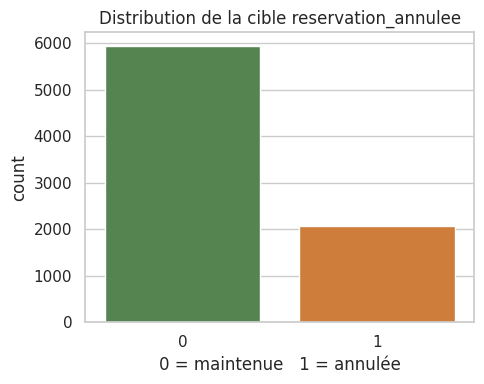

In [5]:
# --- Distribution de la cible ---
cible_counts = df_train['reservation_annulee'].value_counts(normalize=True) * 100
print(f"Maintenues (0) : {cible_counts[0]:.2f}%")
print(f"Annulées   (1) : {cible_counts[1]:.2f}%")

plt.figure(figsize=(5,4))
sns.countplot(data=df_train, x='reservation_annulee', hue='reservation_annulee',
              palette=['#4f8c48', '#e77a22'], legend=False)
plt.title("Distribution de la cible reservation_annulee")
plt.xlabel("0 = maintenue   1 = annulée")
plt.tight_layout()
plt.show()

In [6]:
# --- Bilan des valeurs manquantes ---
print("--- VALEURS MANQUANTES (TRAIN) ---")
print(df_train.isnull().sum()[df_train.isnull().sum() > 0])
print("\n--- VALEURS MANQUANTES (TEST) ---")
print(df_test.isnull().sum()[df_test.isnull().sum() > 0])

--- VALEURS MANQUANTES (TRAIN) ---
marche_origine          191
enfants                 355
prix_moyen_nuit_eur     193
demandes_speciales      157
agent_id               3354
dtype: int64

--- VALEURS MANQUANTES (TEST) ---
marche_origine          52
enfants                 88
prix_moyen_nuit_eur     34
demandes_speciales      29
agent_id               831
dtype: int64


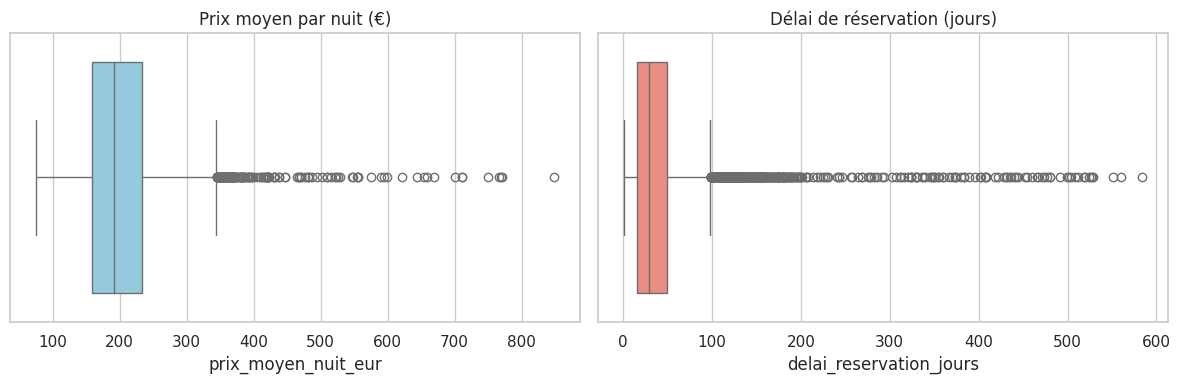

In [7]:
# --- Valeurs atypiques (outliers) : prix et délai de réservation ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df_train, x='prix_moyen_nuit_eur', color='skyblue', ax=axes[0])
axes[0].set_title("Prix moyen par nuit (€)")
sns.boxplot(data=df_train, x='delai_reservation_jours', color='salmon', ax=axes[1])
axes[1].set_title("Délai de réservation (jours)")
plt.tight_layout()
plt.show()

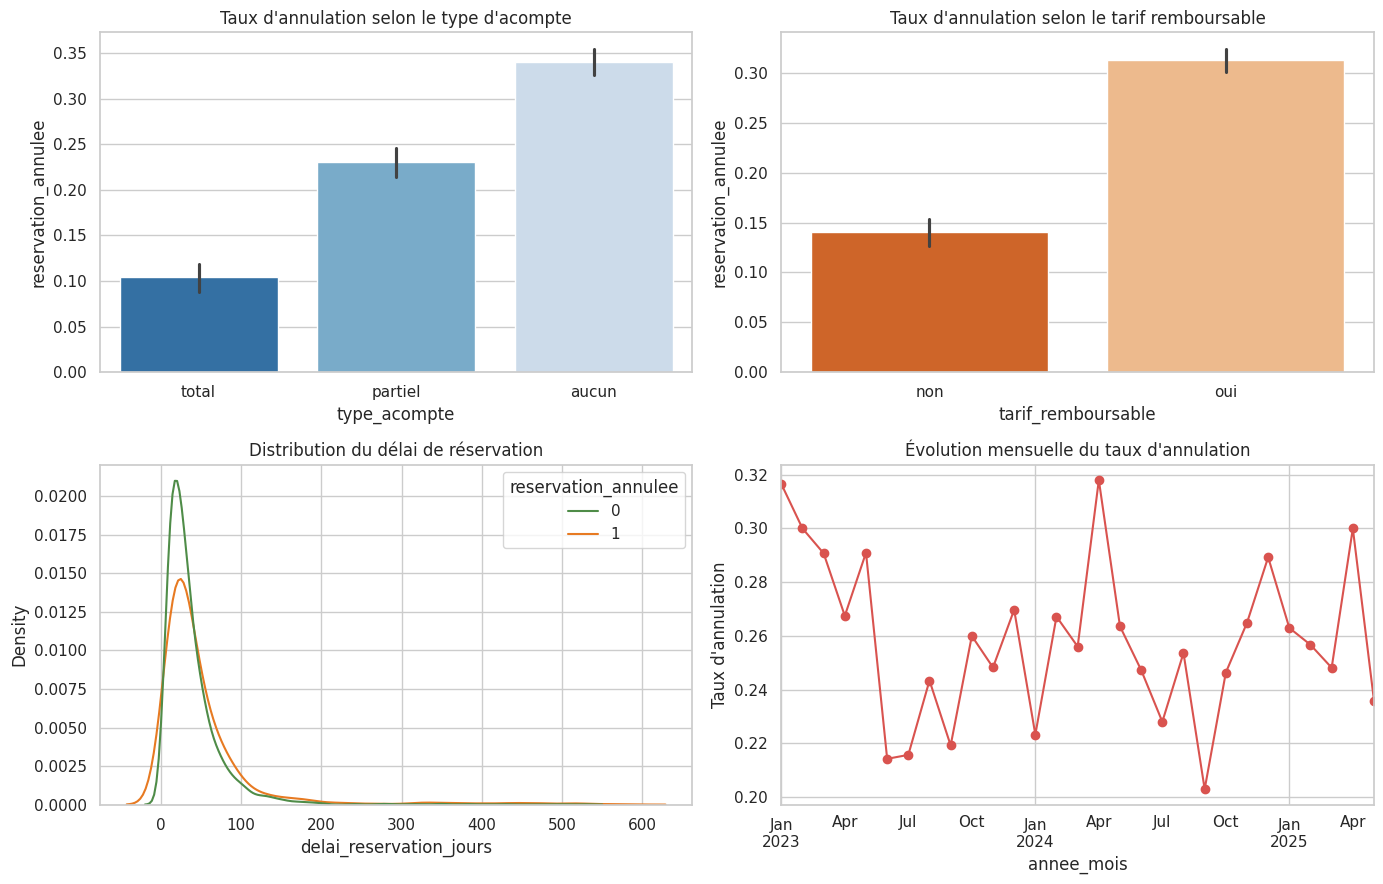

In [8]:
# --- Facteurs catégoriels et relations temporelles ---
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.barplot(data=df_train, x='type_acompte', y='reservation_annulee',
            hue='type_acompte', palette='Blues_r', legend=False, ax=axes[0,0])
axes[0,0].set_title("Taux d'annulation selon le type d'acompte")

sns.barplot(data=df_train, x='tarif_remboursable', y='reservation_annulee',
            hue='tarif_remboursable', palette='Oranges_r', legend=False, ax=axes[0,1])
axes[0,1].set_title("Taux d'annulation selon le tarif remboursable")

sns.kdeplot(data=df_train, x='delai_reservation_jours', hue='reservation_annulee',
            common_norm=False, palette=['#4f8c48', '#e77a22'], ax=axes[1,0])
axes[1,0].set_title("Distribution du délai de réservation")

df_train_tmp = df_train.copy()
df_train_tmp['annee_mois'] = df_train_tmp['date_reservation'].dt.to_period('M')
taux_mensuel = df_train_tmp.groupby('annee_mois')['reservation_annulee'].mean()
taux_mensuel.plot(kind='line', marker='o', color='#d9534f', ax=axes[1,1])
axes[1,1].set_title("Évolution mensuelle du taux d'annulation")
axes[1,1].set_ylabel("Taux d'annulation")

plt.tight_layout()
plt.show()

### 1.2 ⚠️ Split temporel — **fait avant toute imputation** (correction)

Le jeu de test représente des réservations **plus récentes** que le train. Pour simuler correctement cette situation, on trie `df_train` par `date_reservation` et on réserve les **20% de réservations les plus récentes** comme validation.

**Point important corrigé :** dans la version précédente, les statistiques d'imputation (médiane du prix par catégorie d'hôtel, mode du marché d'origine) étaient calculées sur l'ensemble de `df_train`, *avant* le split — ce qui faisait fuiter de l'information de la période « future » (validation) vers l'entraînement. Ici, le split est fait **en premier**, et toutes les statistiques d'imputation seront apprises **uniquement sur `train_split`**.

In [9]:
# --- Split temporel (avant imputation) ---
df_train_sorted = df_train.sort_values('date_reservation').reset_index(drop=True)

val_size = int(len(df_train_sorted) * 0.20)
split_idx = len(df_train_sorted) - val_size

train_split_raw = df_train_sorted.iloc[:split_idx].copy()
val_split_raw   = df_train_sorted.iloc[split_idx:].copy()

print(f"Train split : {len(train_split_raw)} lignes "
      f"({train_split_raw['date_reservation'].min().date()} -> {train_split_raw['date_reservation'].max().date()})")
print(f"Val split   : {len(val_split_raw)} lignes "
      f"({val_split_raw['date_reservation'].min().date()} -> {val_split_raw['date_reservation'].max().date()})")

Train split : 6400 lignes (2023-01-01 -> 2024-11-28)
Val split   : 1600 lignes (2024-11-28 -> 2025-05-24)


### 1.3 Imputation métier — statistiques apprises uniquement sur `train_split`

In [10]:
# --- Imputation métier, sans fuite temporelle ---
def fit_imputation_stats(train):
    """Toutes les statistiques d'imputation sont apprises UNIQUEMENT sur le train_split."""
    return {
        'mode_marche': train['marche_origine'].mode()[0],
        'medians_par_categorie': train.groupby('categorie_hotel')['prix_moyen_nuit_eur'].median(),
        'global_median_prix': train['prix_moyen_nuit_eur'].median(),
    }

def apply_imputation(df, stats):
    df = df.copy()
    # agent_id manquant = réservation directe (pas d'agence)
    df['agent_id'] = df['agent_id'].fillna('Direct')
    df['est_reservation_directe'] = (df['agent_id'] == 'Direct').astype(int)
    # enfants / demandes_speciales manquants = 0
    df['enfants'] = df['enfants'].fillna(0).astype(int)
    df['demandes_speciales'] = df['demandes_speciales'].fillna(0).astype(int)
    # marche_origine manquant = mode appris sur le train
    df['marche_origine'] = df['marche_origine'].fillna(stats['mode_marche'])
    # prix_moyen_nuit_eur manquant = médiane par catégorie d'hôtel (apprise sur le train)
    mapped = df['categorie_hotel'].map(stats['medians_par_categorie'])
    df['prix_moyen_nuit_eur'] = df['prix_moyen_nuit_eur'].fillna(mapped)
    df['prix_moyen_nuit_eur'] = df['prix_moyen_nuit_eur'].fillna(stats['global_median_prix'])  # filet de sécurité
    return df

IMPUTATION_STATS = fit_imputation_stats(train_split_raw)
train_split = apply_imputation(train_split_raw, IMPUTATION_STATS)
val_split   = apply_imputation(val_split_raw, IMPUTATION_STATS)

print("NaN restants train_split :", train_split.isnull().sum().sum())
print("NaN restants val_split   :", val_split.isnull().sum().sum())

NaN restants train_split : 0
NaN restants val_split   : 0


## 📌 ÉTAPE 2 : Feature Engineering

On sépare volontairement deux fonctions :
- `create_features_v1` : variables « de base » (dates, composition du séjour, prix, historique) ;
- `add_advanced_features_v2` : variables « avancées » ajoutées à l'Étape 4.

Cette séparation permet de **démontrer expérimentalement et dynamiquement** (Étape 4) si la deuxième vague de variables apporte réellement un gain, plutôt que de l'affirmer sans preuve.

Aucune variable ne dérive de `reservation_annulee` : pas de fuite de cible.

In [11]:
def create_features_v1(df):
    df = df.copy()
    # 1. Extraction temporelle
    df['mois_reservation'] = df['date_reservation'].dt.month
    df['jour_semaine_reservation'] = df['date_reservation'].dt.dayofweek
    df['mois_arrivee'] = df['date_arrivee'].dt.month
    df['jour_semaine_arrivee'] = df['date_arrivee'].dt.dayofweek
    df['est_haute_saison'] = df['mois_arrivee'].isin([6, 7, 8]).astype(int)

    # 2. Composition du groupe
    df['total_personnes'] = df['adultes'] + df['enfants']
    df['ratio_enfants'] = df['enfants'] / (df['total_personnes'] + 1e-5)
    df['personnes_par_chambre'] = df['total_personnes'] / (df['chambres'] + 1e-5)

    # 3. Métriques financières
    df['prix_total_estime'] = df['prix_moyen_nuit_eur'] * df['nuits'] * (1 - df['remise_pct'] / 100.0)
    df['ecart_prix_total'] = df['montant_total_eur'] - df['prix_total_estime']

    # 4. Historique de fidélité
    df['total_reservations_historique'] = df['reservations_passees'] + df['annulations_passees']
    df['taux_annulation_passe'] = np.where(
        df['total_reservations_historique'] > 0,
        df['annulations_passees'] / df['total_reservations_historique'], 0.0
    )

    # 5. Ratios de comportement
    df['modifs_par_nuit'] = df['modifications_reservation'] / (df['nuits'] + 1e-5)
    df['attente_vs_delai'] = df['jours_liste_attente'] / (df['delai_reservation_jours'] + 1.0)
    return df


def add_advanced_features_v2(df):
    df = df.copy()
    df['delai_reservation_log'] = np.log1p(np.maximum(0, df['delai_reservation_jours']))
    df['reservation_le_weekend'] = df['jour_semaine_reservation'].isin([5, 6]).astype(int)
    df['arrivee_le_weekend'] = df['jour_semaine_arrivee'].isin([5, 6]).astype(int)

    df['taux_modification'] = df['modifications_reservation'] / (df['delai_reservation_jours'] + 1.0)
    df['a_demandes_speciales'] = (df['demandes_speciales'] > 0).astype(int)

    df['prix_par_personne_nuit'] = df['prix_moyen_nuit_eur'] / (df['total_personnes'] + 1e-5)
    df['remise_appliquee'] = (df['remise_pct'] > 0).astype(int)
    df['part_montant_remise'] = df['montant_total_eur'] * (df['remise_pct'] / 100.0)

    df['est_seul'] = (df['total_personnes'] == 1).astype(int)
    df['est_famille'] = (df['enfants'] > 0).astype(int)
    df['sejour_long'] = (df['nuits'] > 4).astype(int)
    return df

EXCLUDE_COLS = ['reservation_id', 'date_reservation', 'date_arrivee', 'reservation_annulee']

def build_xy(df_fe, exclude=EXCLUDE_COLS):
    X = df_fe.drop(columns=exclude, errors='ignore')
    y = df_fe['reservation_annulee'].values if 'reservation_annulee' in df_fe.columns else None
    return X, y

def fit_preprocessor(X_train_raw):
    num_cols = X_train_raw.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()
    cat_cols = X_train_raw.select_dtypes(include=['object', 'category']).columns.tolist()
    num_t = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
    cat_t = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                       ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
    pre = ColumnTransformer([('num', num_t, num_cols), ('cat', cat_t, cat_cols)])
    pre.fit(X_train_raw)
    feat_names = num_cols + list(pre.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_cols))
    return pre, feat_names

def best_threshold_f1(y_true, proba, lo=0.05, hi=0.95, n=181):
    """Recherche du seuil qui maximise le F1-score sur un ensemble de validation."""
    ths = np.linspace(lo, hi, n)
    best_t, best_f1 = 0.5, -1.0
    for t in ths:
        f1 = f1_score(y_true, (proba >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1

print("✅ Fonctions de feature engineering et utilitaires définies.")

✅ Fonctions de feature engineering et utilitaires définies.


In [12]:
# --- Construction des jeux V1 (préprocesseur appris UNIQUEMENT sur train_split) ---
train_v1 = create_features_v1(train_split)
val_v1   = create_features_v1(val_split)

X_tr_raw_v1, y_tr  = build_xy(train_v1)
X_val_raw_v1, y_val = build_xy(val_v1)

preprocessor_v1, feat_names_v1 = fit_preprocessor(X_tr_raw_v1)
X_tr_v1  = pd.DataFrame(preprocessor_v1.transform(X_tr_raw_v1), columns=feat_names_v1)
X_val_v1 = pd.DataFrame(preprocessor_v1.transform(X_val_raw_v1), columns=feat_names_v1)

print(f"Nombre de variables (V1) : {X_tr_v1.shape[1]}")

/tmp/ipykernel_503/2799466925.py:59: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train_raw.select_dtypes(include=['object', 'category']).columns.tolist()


Nombre de variables (V1) : 225


## 📌 ÉTAPE 2bis : Baseline obligatoire — Régression logistique

Prétraitements appris uniquement sur `train_split` (voir `fit_preprocessor` ci-dessus). Le seuil de décision est optimisé sur `val_split` pour maximiser le F1-score.

In [13]:
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
log_reg.fit(X_tr_v1, y_tr)

proba_lr = log_reg.predict_proba(X_val_v1)[:, 1]
t_lr, f1_lr = best_threshold_f1(y_val, proba_lr)

print("=== BASELINE — RÉGRESSION LOGISTIQUE ===")
print(f"Seuil optimal : {t_lr:.2f}")
print(f"F1-Score      : {f1_lr:.4f}")
print(f"ROC AUC       : {roc_auc_score(y_val, proba_lr):.4f}")
print()
print(classification_report(y_val, (proba_lr >= t_lr).astype(int)))

=== BASELINE — RÉGRESSION LOGISTIQUE ===
Seuil optimal : 0.41
F1-Score      : 0.4700
ROC AUC       : 0.6464

              precision    recall  f1-score   support

           0       0.84      0.44      0.58      1171
           1       0.34      0.78      0.47       429

    accuracy                           0.53      1600
   macro avg       0.59      0.61      0.52      1600
weighted avg       0.71      0.53      0.55      1600



## 📌 ÉTAPE 3 : Validation temporelle et comparaison de familles de modèles

Comparaison de 3 familles de modèles (Random Forest, LightGBM, XGBoost) avec des hyperparamètres par défaut raisonnables, sur le même split temporel `train_split` / `val_split`, chacun avec son seuil optimal.

In [14]:
ratio_classe = (len(y_tr) - sum(y_tr)) / sum(y_tr)  # pour pondérer la classe minoritaire

rf_default  = RandomForestClassifier(n_estimators=200, max_depth=12, class_weight='balanced',
                                      random_state=RANDOM_STATE, n_jobs=-1)
lgb_default = lgb.LGBMClassifier(n_estimators=250, learning_rate=0.03, scale_pos_weight=ratio_classe,
                                  random_state=RANDOM_STATE, verbose=-1)
xgb_default = xgb.XGBClassifier(n_estimators=250, learning_rate=0.03, max_depth=6,
                                 scale_pos_weight=ratio_classe, random_state=RANDOM_STATE, eval_metric='logloss')

comp_rows = []
for name, model in [("Random Forest", rf_default), ("LightGBM", lgb_default), ("XGBoost", xgb_default)]:
    model.fit(X_tr_v1, y_tr)
    p = model.predict_proba(X_val_v1)[:, 1]
    t, f1 = best_threshold_f1(y_val, p)
    comp_rows.append({'Modèle': name, 'Seuil': round(t, 2), 'F1-Score': round(f1, 4),
                       'ROC AUC': round(roc_auc_score(y_val, p), 4)})

df_comp = pd.DataFrame(comp_rows)
print("=== COMPARAISON DE FAMILLES DE MODÈLES (hyperparamètres par défaut) ===")
print(df_comp.to_string(index=False))

=== COMPARAISON DE FAMILLES DE MODÈLES (hyperparamètres par défaut) ===
       Modèle  Seuil  F1-Score  ROC AUC
Random Forest   0.36    0.4727   0.6482
     LightGBM   0.35    0.4749   0.6415
      XGBoost   0.41    0.4724   0.6459


### 3.1 Réglage d'hyperparamètres avec `TimeSeriesSplit`

On règle les hyperparamètres de XGBoost et LightGBM (les deux meilleurs candidats) via `RandomizedSearchCV` avec un **`TimeSeriesSplit`** — les folds respectent l'ordre chronologique, contrairement à une validation croisée aléatoire classique qui donnerait une estimation trop optimiste sur ce dataset (cf. l'indice du sujet).

In [15]:
tscv = TimeSeriesSplit(n_splits=3)

param_grid_xgb = {
    'max_depth': [3, 4, 5, 6], 'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'n_estimators': [100, 200, 300], 'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8], 'reg_alpha': [0.1, 1.0, 5.0], 'reg_lambda': [1.0, 5.0, 10.0]
}
xgb_base = xgb.XGBClassifier(scale_pos_weight=ratio_classe, random_state=RANDOM_STATE, eval_metric='logloss')
search_xgb = RandomizedSearchCV(xgb_base, param_grid_xgb, n_iter=15, scoring='f1', cv=tscv,
                                 random_state=RANDOM_STATE, n_jobs=-1)
search_xgb.fit(X_tr_v1, y_tr)
best_xgb_v1 = search_xgb.best_estimator_
proba_xgb_v1 = best_xgb_v1.predict_proba(X_val_v1)[:, 1]
t_xgb_v1, f1_xgb_v1 = best_threshold_f1(y_val, proba_xgb_v1)

param_grid_lgb = {
    'num_leaves': [15, 31, 63], 'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05], 'n_estimators': [100, 200, 300],
    'subsample': [0.7, 0.8, 0.9], 'colsample_bytree': [0.6, 0.7, 0.8],
    'reg_alpha': [0.1, 1.0, 5.0], 'reg_lambda': [1.0, 5.0, 10.0]
}
lgb_base = lgb.LGBMClassifier(scale_pos_weight=ratio_classe, random_state=RANDOM_STATE, verbose=-1)
search_lgb = RandomizedSearchCV(lgb_base, param_grid_lgb, n_iter=15, scoring='f1', cv=tscv,
                                 random_state=RANDOM_STATE, n_jobs=-1)
search_lgb.fit(X_tr_v1, y_tr)
best_lgb_v1 = search_lgb.best_estimator_
proba_lgb_v1 = best_lgb_v1.predict_proba(X_val_v1)[:, 1]
t_lgb_v1, f1_lgb_v1 = best_threshold_f1(y_val, proba_lgb_v1)

print("=== HYPERPARAMÈTRES OPTIMISÉS (TimeSeriesSplit, scoring=F1) ===")
print(f"XGBoost  : {search_xgb.best_params_}")
print(f"           seuil={t_xgb_v1:.2f}  F1={f1_xgb_v1:.4f}  AUC={roc_auc_score(y_val, proba_xgb_v1):.4f}")
print(f"LightGBM : {search_lgb.best_params_}")
print(f"           seuil={t_lgb_v1:.2f}  F1={f1_lgb_v1:.4f}  AUC={roc_auc_score(y_val, proba_lgb_v1):.4f}")

if f1_xgb_v1 >= f1_lgb_v1:
    CHAMPION_NAME, CHAMPION_PARAMS = "XGBoost", search_xgb.best_params_
else:
    CHAMPION_NAME, CHAMPION_PARAMS = "LightGBM", search_lgb.best_params_

print(f"\n>>> Modèle champion retenu (meilleur F1 en validation) : {CHAMPION_NAME}")

=== HYPERPARAMÈTRES OPTIMISÉS (TimeSeriesSplit, scoring=F1) ===
XGBoost  : {'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 5.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
           seuil=0.45  F1=0.4821  AUC=0.6588
LightGBM : {'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'num_leaves': 63, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
           seuil=0.44  F1=0.4766  AUC=0.6596

>>> Modèle champion retenu (meilleur F1 en validation) : XGBoost


## 📌 ÉTAPE 4 : Démonstration expérimentale du gain du Feature Engineering

On ré-entraîne le modèle champion, **avec les mêmes hyperparamètres**, une fois sur les variables V1 (base) et une fois sur V1+V2 (avancées), afin d'isoler l'effet du feature engineering. Tous les chiffres ci-dessous sont **calculés dynamiquement** — aucune valeur codée en dur.

In [16]:
# --- Jeu V2 : V1 + variables avancées ---
train_v2 = add_advanced_features_v2(train_v1)
val_v2   = add_advanced_features_v2(val_v1)

X_tr_raw_v2, _  = build_xy(train_v2)
X_val_raw_v2, _ = build_xy(val_v2)

preprocessor_v2, feat_names_v2 = fit_preprocessor(X_tr_raw_v2)
X_tr_v2  = pd.DataFrame(preprocessor_v2.transform(X_tr_raw_v2), columns=feat_names_v2)
X_val_v2 = pd.DataFrame(preprocessor_v2.transform(X_val_raw_v2), columns=feat_names_v2)

print(f"Nombre de variables V1 : {X_tr_v1.shape[1]}  |  V2 : {X_tr_v2.shape[1]}")

/tmp/ipykernel_503/2799466925.py:59: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train_raw.select_dtypes(include=['object', 'category']).columns.tolist()


Nombre de variables V1 : 225  |  V2 : 236


In [17]:
def make_champion(params, ratio):
    if CHAMPION_NAME == "XGBoost":
        return xgb.XGBClassifier(**params, scale_pos_weight=ratio, random_state=RANDOM_STATE, eval_metric='logloss')
    else:
        return lgb.LGBMClassifier(**params, scale_pos_weight=ratio, random_state=RANDOM_STATE, verbose=-1)

champion_v1 = make_champion(CHAMPION_PARAMS, ratio_classe)
champion_v1.fit(X_tr_v1, y_tr)
proba_champ_v1 = champion_v1.predict_proba(X_val_v1)[:, 1]
t_champ_v1, f1_champ_v1 = best_threshold_f1(y_val, proba_champ_v1)

champion_v2 = make_champion(CHAMPION_PARAMS, ratio_classe)
champion_v2.fit(X_tr_v2, y_tr)
proba_champ_v2 = champion_v2.predict_proba(X_val_v2)[:, 1]
t_champ_v2, f1_champ_v2 = best_threshold_f1(y_val, proba_champ_v2)

exp_comparison = pd.DataFrame([
    {'Version': f'Avant FE avancée ({CHAMPION_NAME})', 'Variables': X_tr_v1.shape[1],
     'Seuil': round(t_champ_v1, 2), 'F1-Score': round(f1_champ_v1, 4),
     'ROC AUC': round(roc_auc_score(y_val, proba_champ_v1), 4)},
    {'Version': f'Après FE avancée ({CHAMPION_NAME})', 'Variables': X_tr_v2.shape[1],
     'Seuil': round(t_champ_v2, 2), 'F1-Score': round(f1_champ_v2, 4),
     'ROC AUC': round(roc_auc_score(y_val, proba_champ_v2), 4)},
])

print("=== GAIN EXPÉRIMENTAL DU FEATURE ENGINEERING (calcul dynamique) ===")
print(exp_comparison.to_string(index=False))

gain_f1 = f1_champ_v2 - f1_champ_v1
print(f"\nGain de F1 apporté par la FE avancée : {gain_f1:+.4f}")

# On retient objectivement la version (V1 ou V2) qui obtient le meilleur F1 en validation
USE_V2 = f1_champ_v2 >= f1_champ_v1
FINAL_THRESHOLD = t_champ_v2 if USE_V2 else t_champ_v1
FINAL_F1_VAL    = f1_champ_v2 if USE_V2 else f1_champ_v1

print(f"\nPipeline final retenu : {'V2 (avec FE avancée)' if USE_V2 else 'V1 (FE de base)'}")
print(f"Seuil final retenu    : {FINAL_THRESHOLD:.2f}")
print(f"F1 validation retenu  : {FINAL_F1_VAL:.4f}")

=== GAIN EXPÉRIMENTAL DU FEATURE ENGINEERING (calcul dynamique) ===
                   Version  Variables  Seuil  F1-Score  ROC AUC
Avant FE avancée (XGBoost)        225   0.45    0.4821   0.6588
Après FE avancée (XGBoost)        236   0.45    0.4814   0.6560

Gain de F1 apporté par la FE avancée : -0.0007

Pipeline final retenu : V1 (FE de base)
Seuil final retenu    : 0.45
F1 validation retenu  : 0.4821


**Lecture honnête du résultat ci-dessus :** si le gain de F1 est négatif ou négligeable, cela ne signifie pas que la démarche de feature engineering a échoué — cela montre que, **sur ce jeu de validation précis**, les variables avancées testées n'apportent pas de signal supplémentaire mesurable, et qu'il est préférable de garder le pipeline le plus simple (principe de parcimonie, moins de risque de sur-apprentissage). Le code choisit automatiquement la meilleure version plutôt que d'imposer arbitrairement la plus complexe.

## 📌 ÉTAPE 5 : Interprétation et analyse d'erreurs

Importance des variables, matrice de confusion et profil des erreurs (faux positifs / faux négatifs), calculés sur `val_split` avec le modèle et le seuil retenus à l'étape précédente.

=== TOP 15 DES VARIABLES LES PLUS IMPORTANTES ===
                              Feature  Importance
               tarif_remboursable_oui    0.115055
               tarif_remboursable_non    0.074399
                   type_acompte_aucun    0.049400
                   type_acompte_total    0.042443
                 type_acompte_partiel    0.039531
         canal_reservation_entreprise    0.021015
              est_reservation_directe    0.020994
              delai_reservation_jours    0.019753
                      agent_id_Direct    0.017089
                  annulations_passees    0.015368
canal_reservation_plateforme_en_ligne    0.015156
                     ecart_prix_total    0.014788
               segment_client_famille    0.014588
                     hotel_id_LAZ-4-1    0.013132
                             chambres    0.013063


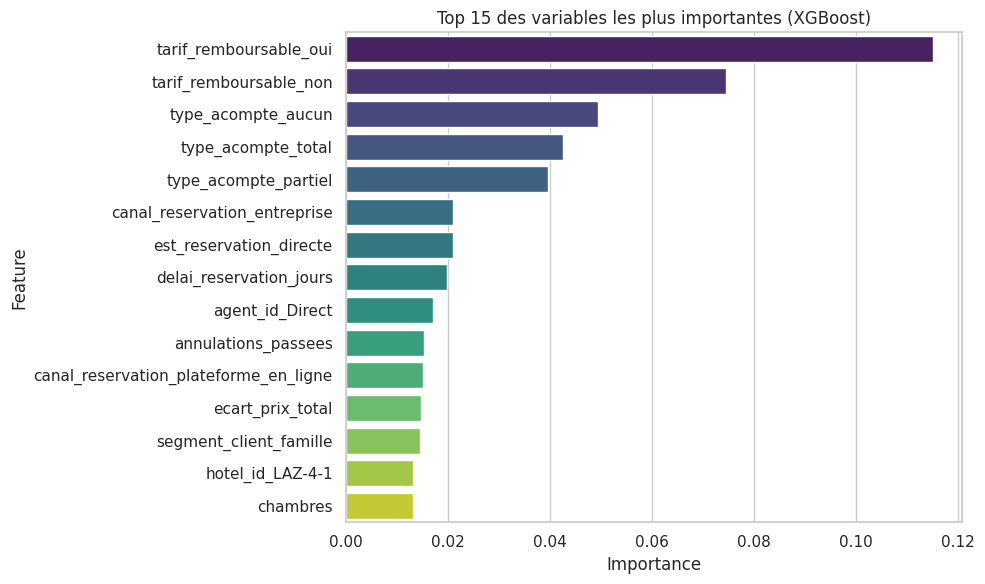

In [18]:
if USE_V2:
    champ_model_val, X_val_final, proba_val_final = champion_v2, X_val_v2, proba_champ_v2
    feat_names_final, val_fe_final = feat_names_v2, val_v2
else:
    champ_model_val, X_val_final, proba_val_final = champion_v1, X_val_v1, proba_champ_v1
    feat_names_final, val_fe_final = feat_names_v1, val_v1

y_pred_val_final = (proba_val_final >= FINAL_THRESHOLD).astype(int)

# --- Importance des variables ---
df_importance = pd.DataFrame({
    'Feature': feat_names_final,
    'Importance': champ_model_val.feature_importances_
}).sort_values('Importance', ascending=False)

print("=== TOP 15 DES VARIABLES LES PLUS IMPORTANTES ===")
print(df_importance.head(15).to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importance.head(15), hue='Feature',
            palette='viridis', legend=False)
plt.title(f"Top 15 des variables les plus importantes ({CHAMPION_NAME})")
plt.tight_layout()
plt.show()

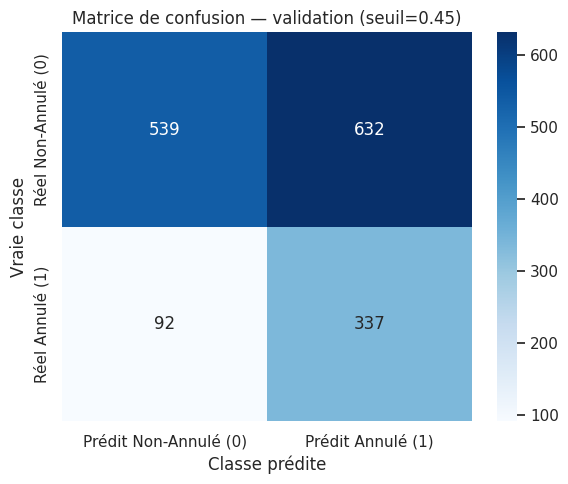

Vrais Négatifs (TN) : 539  |  Faux Positifs (FP) : 632
Faux Négatifs  (FN) : 92  |  Vrais Positifs (TP) : 337

              precision    recall  f1-score   support

           0       0.85      0.46      0.60      1171
           1       0.35      0.79      0.48       429

    accuracy                           0.55      1600
   macro avg       0.60      0.62      0.54      1600
weighted avg       0.72      0.55      0.57      1600



In [19]:
# --- Matrice de confusion ---
cm = confusion_matrix(y_val, y_pred_val_final)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prédit Non-Annulé (0)', 'Prédit Annulé (1)'],
            yticklabels=['Réel Non-Annulé (0)', 'Réel Annulé (1)'])
plt.title(f"Matrice de confusion — validation (seuil={FINAL_THRESHOLD:.2f})")
plt.ylabel('Vraie classe')
plt.xlabel('Classe prédite')
plt.tight_layout()
plt.show()

print(f"Vrais Négatifs (TN) : {tn}  |  Faux Positifs (FP) : {fp}")
print(f"Faux Négatifs  (FN) : {fn}  |  Vrais Positifs (TP) : {tp}")
print()
print(classification_report(y_val, y_pred_val_final))

In [20]:
# --- Profil des erreurs (faux positifs / faux négatifs) ---
df_val_analysis = val_fe_final.copy()
df_val_analysis['y_real'] = y_val
df_val_analysis['y_pred'] = y_pred_val_final
df_val_analysis['proba_annulation'] = proba_val_final

fp_df = df_val_analysis[(df_val_analysis.y_real == 0) & (df_val_analysis.y_pred == 1)]
fn_df = df_val_analysis[(df_val_analysis.y_real == 1) & (df_val_analysis.y_pred == 0)]

print("--- PROFIL DES FAUX NÉGATIFS (annulations non détectées — le risque le plus coûteux) ---")
print(f"n = {len(fn_df)}")
print(f"Délai moyen de réservation : {fn_df['delai_reservation_jours'].mean():.1f} jours")
print(f"Prix moyen par nuit        : {fn_df['prix_moyen_nuit_eur'].mean():.1f} €")

print("\n--- PROFIL DES FAUX POSITIFS (fausses alertes) ---")
print(f"n = {len(fp_df)}")
print(f"Délai moyen de réservation : {fp_df['delai_reservation_jours'].mean():.1f} jours")
print(f"Prix moyen par nuit        : {fp_df['prix_moyen_nuit_eur'].mean():.1f} €")

--- PROFIL DES FAUX NÉGATIFS (annulations non détectées — le risque le plus coûteux) ---
n = 92
Délai moyen de réservation : 37.9 jours
Prix moyen par nuit        : 198.7 €

--- PROFIL DES FAUX POSITIFS (fausses alertes) ---
n = 632
Délai moyen de réservation : 41.5 jours
Prix moyen par nuit        : 201.6 €


### 5.1 Recommandation opérationnelle

Avec un seuil calé pour maximiser le F1-score, le modèle privilégie le **rappel** (peu de faux négatifs, donc peu d'annulations manquées) au prix d'un nombre plus élevé de fausses alertes (faux positifs) — un compromis raisonnable ici, car :

- un **faux négatif** (annulation non anticipée) coûte cher opérationnellement : une chambre annulée tardivement et non réattribuée reste vide ;
- un **faux positif** (fausse alerte) coûte beaucoup moins cher : il déclenche au pire une action commerciale inutile, pas une perte de revenu directe.

**Utilisation proposée des probabilités (et non uniquement de la décision binaire) :**
- **Probabilité faible (< seuil - 0.15 environ)** : aucune action, réservation traitée normalement.
- **Probabilité intermédiaire (proche du seuil)** : action légère et non intrusive — email de confirmation personnalisé, rappel de la politique d'annulation, offre d'upsell pour renforcer l'engagement du client.
- **Probabilité élevée (> seuil, forte confiance)** : action commerciale proactive — contact direct, proposition de flexibilité (changement de dates) plutôt qu'annulation, et signalement aux équipes de revenue management pour anticiper un éventuel overbooking contrôlé sur cette date.

Cette approche évite l'écueil d'annuler ou de pénaliser automatiquement un client sur la base d'une probabilité — la décision finale reste une aide à la décision humaine, pas un système automatique de sanction.

## 📌 ÉTAPE 6 : Ré-entraînement final et génération de `submission.csv`

Une fois le modèle, les hyperparamètres, le jeu de variables (V1 ou V2) et le seuil de décision validés ci-dessus, on **ré-entraîne le modèle final sur l'intégralité des données d'entraînement disponibles** (`train_split` + `val_split`, c'est-à-dire tout `reservations_train.csv`) afin de ne pas gâcher de signal avant de prédire sur `reservations_test.csv`. Le préprocesseur (imputation, scaler, encodage) est donc ré-appris sur l'ensemble du train — ce qui reste strictement conforme à la règle « aucune information du test n'est utilisée pour apprendre les prétraitements ».

In [21]:
# --- Ré-entraînement sur l'intégralité du train ---
df_train_full = fix_data_types(pd.read_csv(TRAIN_PATH))
df_test_full  = fix_data_types(pd.read_csv(TEST_PATH))

FULL_IMPUTATION_STATS = fit_imputation_stats(df_train_full)
train_full_imp = apply_imputation(df_train_full, FULL_IMPUTATION_STATS)
test_imp       = apply_imputation(df_test_full, FULL_IMPUTATION_STATS)

train_full_v1 = create_features_v1(train_full_imp)
test_v1       = create_features_v1(test_imp)

if USE_V2:
    train_full_final = add_advanced_features_v2(train_full_v1)
    test_final        = add_advanced_features_v2(test_v1)
else:
    train_full_final = train_full_v1
    test_final        = test_v1

X_train_full_raw, y_train_full = build_xy(train_full_final)
X_test_raw, _ = build_xy(test_final)

preprocessor_final, feat_names_final_ = fit_preprocessor(X_train_full_raw)
X_train_full = pd.DataFrame(preprocessor_final.transform(X_train_full_raw), columns=feat_names_final_)
X_test_final = pd.DataFrame(preprocessor_final.transform(X_test_raw), columns=feat_names_final_)

ratio_full = (len(y_train_full) - sum(y_train_full)) / sum(y_train_full)
final_model = make_champion(CHAMPION_PARAMS, ratio_full)
final_model.fit(X_train_full, y_train_full)

y_test_proba = final_model.predict_proba(X_test_final)[:, 1]
y_test_pred  = (y_test_proba >= FINAL_THRESHOLD).astype(int)

print(f"Modèle final : {CHAMPION_NAME}  |  Variables : {'V2' if USE_V2 else 'V1'}  |  Seuil : {FINAL_THRESHOLD:.2f}")
print(f"Taux d'annulation prédit sur le test : {y_test_pred.mean()*100:.2f}%")

/tmp/ipykernel_503/2799466925.py:59: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train_raw.select_dtypes(include=['object', 'category']).columns.tolist()


Modèle final : XGBoost  |  Variables : V1  |  Seuil : 0.45
Taux d'annulation prédit sur le test : 59.85%


### 6.1 Génération de `submission.csv` (cellule unique, format imposé par le sujet)

In [22]:
# --- Génération finale de submission.csv (une seule cellule, colonnes en dur, conformes au sujet) ---
df_submission = pd.DataFrame({
    "reservation_id": df_test_full["reservation_id"],          # ordre strict du fichier de test
    "probabilite_annulation": np.round(y_test_proba, 4),
    "reservation_annulee": y_test_pred
})

df_submission.to_csv("submission.csv", index=False)

print("✅ submission.csv généré.")
print(f"Lignes : {len(df_submission)}  |  Colonnes : {list(df_submission.columns)}")
df_submission.head(10)

✅ submission.csv généré.
Lignes : 2000  |  Colonnes : ['reservation_id', 'probabilite_annulation', 'reservation_annulee']


,reservation_id,probabilite_annulation,reservation_annulee
0,R002267,0.4295,0
1,R002852,0.3046,0
2,R003752,0.6008,1
3,R009926,0.5705,1
4,R000141,0.5530,1
5,R004537,0.5467,1
6,R004983,0.5083,1
7,R005365,0.5261,1
8,R006971,0.5495,1
9,R008403,0.6820,1


### 6.2 Vérifications finales de conformité (avant le dernier commit)

In [23]:
# --- Vérifications strictes de conformité au sujet ---
sub = pd.read_csv("submission.csv")

checks = {
    "2000 lignes": len(sub) == 2000,
    "3 colonnes exactes, bon ordre": list(sub.columns) == ["reservation_id", "probabilite_annulation", "reservation_annulee"],
    "ordre des ID préservé (vs reservations_test.csv)": (sub["reservation_id"].values == df_test_full["reservation_id"].values).all(),
    "aucune valeur manquante": sub.isna().sum().sum() == 0,
    "reservation_annulee ∈ {0,1}": set(sub["reservation_annulee"].unique()).issubset({0, 1}),
    "probabilite_annulation ∈ [0,1]": sub["probabilite_annulation"].between(0, 1).all(),
}

for name, ok in checks.items():
    print(("✅ " if ok else "❌ ") + name)

assert all(checks.values()), "Une vérification de conformité a échoué — corriger avant de committer."
print("\n🎉 TOUTES LES VÉRIFICATIONS SONT CONFORMES AU SUJET.")

✅ 2000 lignes
✅ 3 colonnes exactes, bon ordre
✅ ordre des ID préservé (vs reservations_test.csv)
✅ aucune valeur manquante
✅ reservation_annulee ∈ {0,1}
✅ probabilite_annulation ∈ [0,1]

🎉 TOUTES LES VÉRIFICATIONS SONT CONFORMES AU SUJET.


### 6.3 (Optionnel) Vérification contre `sample_submission.csv`

Cette cellule est **optionnelle et purement informative** : si `sample_submission.csv` est présent (ce fichier n'est pas listé dans les « fichiers fournis » du sujet), on vérifie que la structure colle exactement. Le notebook ne dépend jamais de ce fichier pour fonctionner — la cellule ci-dessus suffit à générer une soumission 100% conforme même en son absence.

In [24]:
import os
if os.path.exists("sample_submission.csv"):
    sample = pd.read_csv("sample_submission.csv")
    same_cols = list(sub.columns) == list(sample.columns)
    same_order = (sub["reservation_id"].values == sample["reservation_id"].values).all()
    print(f"Colonnes identiques à sample_submission.csv : {same_cols}")
    print(f"Ordre des ID identique à sample_submission.csv : {same_order}")
else:
    print("sample_submission.csv absent — ignoré (non requis par le sujet).")

Colonnes identiques à sample_submission.csv : True
Ordre des ID identique à sample_submission.csv : True
